<a href="https://colab.research.google.com/github/babessell1/GWC_Test/blob/main/2D_Animations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ipympl
from google.colab import output
output.enable_custom_widget_manager()
# restart the runtime after running this block!

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.6 MB/s eta 0:00:00


In [1]:
from google.colab import output
output.enable_custom_widget_manager()

In [2]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib ipympl

In [3]:
# variable cheat-sheet
# ==========================
# y(x,t)  - instantaneous wave value (what we visualize)
# A       - amplitude (peak value)
# x, z    - spatial coordinates (1D or 2D)
# Δx      - displacement / source position shift
# λ       - wavelength (distance per cycle)
# k       - wave number = 2π / λ (radians per unit length)
# f       - frequency in cycles/second (Hz)
# ω       - angular frequency = 2π f (radians/second)
# v       - wave speed (length / second). For simple non-dispersive waves: ω = k * v
# φ       - phase offset (radians). If provided in degrees, convert with np.deg2rad()
# r       - distance from a point source to the field point (sqrt(dx^2 + dy^2) in 2D)
# t       - time (seconds)
# i       - the imaginary unit, i² = −1. (it lets us represent a 2D arrow.)

sometimes, we, as programmers, need to use "tricks" to make it easier for the computer to do what we want.
this usually happens when we need the computer to do something many times. in our case, we want to animate our sine wave interactions, but taking sines and square roots is actually quite slow. so we are first going to rewirte our sine wave equation in a way that is faster for the computer to solve.


#Phasor trick
Imagine every sine wave as a little spinning arrow (like a clock hand). The wave value is just the arrow’s vertical shadow. Instead of recomputing lots of sines every frame, we pre‑draw the arrows and spin them — cheap and fast.

The clock‑hand picture (no heavy math)

Take an arrow of length A. Put its tail at the origin.  
Point it at angle θ. The arrow’s vertical shadow (up/down) = A · sin(θ).  
Now make that arrow rotate smoothly — its vertical shadow wiggles in time → it makes a sine wave.

So: sine = vertical shadow of a spinning arrow.

In [4]:
# google "phasor trick, or Euler's formula"

# Euler’s formula:
# e^{iθ} = cos θ + i·sin θ  ⇒  sin θ = Im(e^{iθ}) ... (Im means the imaginary part!)

# Start with the usual wave:
# y(x,t) = A · sin(kx − ωt + φ)

# Rewrite it using eulers formula:
# y(x,t) = Im{ A · e^{i(kx − ωt + φ)} }

# Factor time out:
# y(x,t) = Im{ [A · e^{i(kx + φ)}] · e^{−iωt} }

# Define the spatial arrow (phasor):
# C(x) = A · e^{i(kx + φ)}
#  — this is a fixed arrow at each x.

# Now y(x,t) = Im{ C(x) · e^{−iωt} }
#  — rotate every arrow by the same amount e^{−iωt} and take its vertical shadow

In [5]:
assert 3 == 3, "This is not true"

In [6]:
# ==============================================================================
# Part A — Small 1-D sanity check: traditional sin() vs phasor formulation
# ==============================================================================

def sine_wave_traditional(x, amplitude=1.0, phase_deg=0.0, displacement=0.0, wavelength=1.0):
    """
    The usual real-valued sine definition for 1-D demonstrations:
      y(x) = A * sin( k*(x - displacement) + phi )
    """
    phi = np.deg2rad(float(phase_deg))
    k = 2.0 * np.pi / float(wavelength)
    return amplitude * np.sin(k * (x - displacement) + phi)


def sine_wave_phasor(x, amplitude=1.0, phase_deg=0.0, displacement=0.0, wavelength=1.0, time=0.0, wave_speed=1.0):
    """
    The phasor-based version: build the complex phasor C(x) = A * exp(i*(k*(x-dx) + phi))
    and then return the instantaneous real wave y(x,t) = Im( C(x) * exp(-i * omega * t) ).
    This shows the algebraic equivalence to the traditional sine.
    """
    phi = np.deg2rad(float(phase_deg))
    k = 2.0 * np.pi / float(wavelength)
    omega = 2.0 * np.pi * wave_speed / float(wavelength)
    C = amplitude * np.exp(1j * (k * (x - displacement) + phi))   # complex spatial phasor
    y = np.imag(C * np.exp(-1j * omega * time))                   # rotate in time, then take imaginary part
    return y

# double check!
# are the functions equivalent for t=0 (and at any t, if we include time)?
xs = np.linspace(0, 1, 50)
y_trad = sine_wave_traditional(xs, amplitude=1.23, phase_deg=30, displacement=0.1, wavelength=0.3)
y_phas = sine_wave_phasor(xs, amplitude=1.23, phase_deg=30, displacement=0.1, wavelength=0.3, time=0.0)
assert np.allclose(y_trad, y_phas, atol=1e-12), "Traditional and phasor versions must match (t=0)."

In [7]:
import timeit

# timeit.timeit runs the function 'number' times (default is often 1,000,000)
# and returns the total time taken as a float.
total_time = timeit.timeit(stmt="sine_wave_traditional(1, 1, 2, 10)", setup="from __main__ import sine_wave_traditional", number=1_000_000)
average_time = total_time / 1_000_000

print(f"Average time over 1,000,000 runs: {average_time:.6f} seconds")


Average time over 1,000,000 runs: 0.000008 seconds


In [8]:
import timeit

# timeit.timeit runs the function 'number' times (default is often 1,000,000)
# and returns the total time taken as a float.
total_time = timeit.timeit(stmt="sine_wave_phasor(1, 1, 2, 10)", setup="from __main__ import sine_wave_phasor", number=1_000_000)
average_time = total_time / 1_000_000

print(f"Average time over 1,000,000 runs: {average_time:.6f} seconds")

Average time over 1,000,000 runs: 0.000008 seconds


why is it 3 times slower? I thought we wanted to make it faster!

Well, there is a second part to the trick! For sin(kx+wt+phi) we have an exponenitally increasing combinatorial as x and t increase in the simulation where sin() must be called.

For Im{ [A · e^{i(kx + φ)}] · e^{−iωt} }, we separate t and x and can precalculate them, only needing to recalculate when the frequency or starting positions change.

another trick we can do as programmers, is to precompute what we know we will need for our animation and store it prior to making the animation frames so that it is already ready when we need it, rather than having to calculate it each time on the fly.

*Question: what is memory that is allocated for precomputed, reusable values called?

* Answer cache

In [9]:
import numpy as np
import timeit

def precompute_phasors(x, amps, phases_deg, disps, wavelength):
    k = 2*np.pi / wavelength
    phi = np.deg2rad(phases_deg)
    arg = k*(x[None, :] - disps[:, None]) + phi[:, None]
    # phasor for each wave at each x
    return amps[:, None] * np.exp(1j * arg)

def frames_traditional(x, amps, phases_deg, disps, wavelength, omega, dt, T):
    k = 2*np.pi / wavelength
    phi = np.deg2rad(phases_deg)
    out = 0.0
    for n in range(T):
        t = n * dt
        arg = k*(x[None, :] - disps[:, None]) + phi[:, None] - omega*t
        y = np.sum(amps[:, None] * np.sin(arg), axis=0)
        out += y[0]  # prevent optimization-away
    return out

def frames_phasor(C, omega, dt, T):
    # C is (M,N) complex, precomputed
    rot = np.exp(-1j * omega * dt)  # scalar
    r = 1.0 + 0.0j
    out = 0.0
    for _ in range(T):
        y = np.imag(np.sum(C * r, axis=0))  # sum waves, take imag
        out += y[0]
        r *= rot
    return out

# --- benchmark setup ---
N = 500 # number of spatial points (x)
M = 100 # number of superposed waves
T = 100 # number of frames/time steps
wavelength = 0.3
dt = 0.01
omega = 2*np.pi*3.0   # pick a frequency (3 Hz) for example

rng = np.random.default_rng(0)
x = np.linspace(0, 1, N)
amps = rng.random(M)
phases = rng.uniform(-180, 180, M)
disps = rng.random(M)

C = precompute_phasors(x, amps, phases, disps, wavelength)

# quick correctness spot-check for a couple frames
k = 2*np.pi / wavelength
phi = np.deg2rad(phases)
for n in [0, 5, 17]:
    t = n*dt
    yt = np.sum(amps[:, None] * np.sin(k*(x[None,:]-disps[:,None]) + phi[:,None] - omega*t), axis=0)
    yp = np.imag(np.sum(C * np.exp(-1j*omega*t), axis=0))
    assert np.allclose(yt, yp, atol=1e-12)

number = 10
t_trad = timeit.timeit(lambda: frames_traditional(x, amps, phases, disps, wavelength, omega, dt, T), number=number)
t_phas = timeit.timeit(lambda: frames_phasor(C, omega, dt, T), number=number)

print(f"traditional frames: {t_trad/number:.6e} s/run (T={T})")
print(f"phasor frames:      {t_phas/number:.6e} s/run (T={T})")
print(f"speedup (trad/phas): { (t_trad/t_phas):.3f}x")

traditional frames: 1.083927e-01 s/run (T=100)
phasor frames:      1.077253e-02 s/run (T=100)
speedup (trad/phas): 10.062x


In [14]:
from os import setxattr
def precompute_r_grid(sources, X, Y, eps=1e-12):
  """
  Compute distances r_i(x,y) from each source to each grid point

  Args:
  - sources: (Ns, 2) array of [x,y] positions
  -X, Y: meshgrid arrays of shape (Ny, Nx)
  Note:
  - Ns means number of sources
  - Ny is number of y points in our grid
  - Nx is number of x points in our grid
Returns:
- r_grid: (Ns, Ny, Nx) array of distances
  """
  sx = sources[:, 0][:, None, None]
  sy = sources[:, 1][:, None, None]
  DX = X[None, :, :] - sx
  DY = Y[None, :, :] - sy
  r_grid = np.hypot(DX, DY) + eps   # add tiny eps to avoid division by zero if used
  return r_grid

In [36]:
def precompute_field_coefficient(r_grid, amplitudes, phases_rad, wavelength, decay=False, r_eps=1e-6):
  """
  Precompute complex (imaginary) coefficients for each source and grid point.
  *remember the phasor trick:
  - A_i * sin(k*r - omega*t + phi_i) = Im( A_i * e^(i*(k*r + phi_i)) * e^(-i*omega*t) )
  - So  define C_i(x,y) = A_i * e^(i*(k*r + phi_i))
  - then field(x,y,t)  = Im ( sum_i C_i*e^(-i * omega*t) )
  --> per frame work becomes a single complex multiply and a sum instead of hundreds to thousands of sin() calls

    Inputs:
    - r_grid: (Ns, Ny, Nx)
    - amplidtudes: (Ns, )
    - phases_rad: (Ns, ) radians
    - wavelength: scalar
    Returns:
    --field_coeffs: complex array (Ns, Ny, Nx)
  """
  k = 2.0 * np.pi / float(wavelength)
  amp = amplitudes[:, None, None]
  phi = phases_rad[:, None, None]
  if decay:
      coeffs = amp * np.exp(1j * (k * r_grid + phi)) / (r_grid + r_eps)
  else:
      coeffs = amp * np.exp(1j * (k * r_grid + phi))
  return coeffs


In [37]:
def evaluate_field(field_coeffs, omega, t):
  """
per-rame evalutation when filed_coeffs are precomputed:
- multply by e^(-i*omega*t)
- sum across all sources
- take just the imaginary part
inputs:
-fields_coeffs: (Ns, Ny, Nx)
- omega: amgular freq (scalar)
- t: time (scalar)
returns:
- filed (Ny, Nx) real-valued array
  """
  total = np.sum(field_coeffs * np.exp(-1j * omega * t), axis=0)
  return np.imag(total)

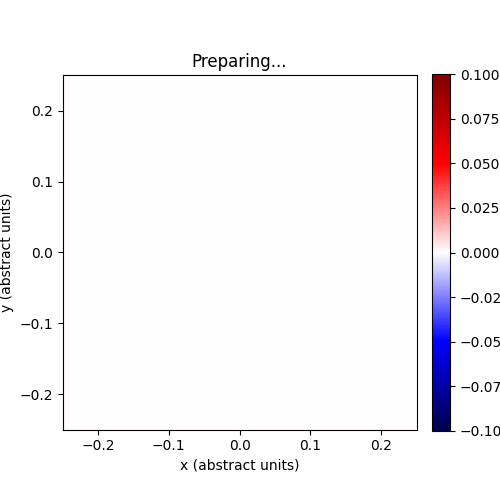

In [39]:
import ipywidgets as widgets

# 1) Define the domain of our simulation and parameters
L = 0.25 # half width of the plotting window
N = 81 # grid resolution per axis (we can reduce this for speed or increase for fidelity)
x = np.linspace(-L, L, N)
y = np.linspace(-L, L, N)
X, Y = np.meshgrid(x, y)
dx = x[1] - x[0] # this is our grid spacing

# working in an ideal, uniless medium, set wave speed to 1
wave_speed = 1.0
fps = 30
nframes = 1000

# 2) initial sources (position are in the same units as X, Y)
init_sources = np.array([[-0.25,  0.00],
                         [ 0.25,  0.00],
                         [ 0.00,  0.25],
                         [ 0.00, -0.25]])

n_sources = init_sources.shape[0]  # takes the first dimension of our array shape
init_amplitudes = np.ones(n_sources) # --> [1, 1, 1, 1]
init_phases_deg = np.zeros(n_sources) # -> [0,0,0,0]

# list comprhension lesson quick:
# list = []
# for i in [1,2,3,4]:
# list.append(i)

# as a comprehension:
# list = [ i for i in [1,2,3,4] ]

# 3 widgets
slider_layout = widgets.Layout(width="240px")
amp_sliders = [
    widgets.FloatSlider(description=f"A{i+1}",
                        value=float(init_amplitudes[i]),
                        min=0.,
                        max=2.,
                        step=0.01,
                        layout=slider_layout,
                        continuous_update=False)
    for i in range(n_sources)
]

phase_sliders = [
    widgets.FloatSlider(description=f"φ{i+1}°", value=float(init_phases_deg[i]),
                        min=0.0, max=360.0, step=1.0,
                        layout=slider_layout, continuous_update=False)
    for i in range(n_sources)
]

x_sliders = [
    widgets.FloatSlider(description=f"x{i+1}", value=float(init_sources[i,0]),
                        min=-0.5, max=0.5, step=0.002,
                        layout=slider_layout, continuous_update=False)
    for i in range(n_sources)
]

y_sliders = [
    widgets.FloatSlider(description=f"y{i+1}", value=float(init_sources[i,1]),
                        min=-0.5, max=0.5, step=0.002,
                        layout=slider_layout, continuous_update=False)
    for i in range(n_sources)
]

wavelength_widget = widgets.FloatSlider(description='wavelength', value=0.2,
                                        min=0.05, max=0.5, step=0.01,
                                        layout=slider_layout, continuous_update=False)

decay_checkbox = widgets.Checkbox(description='Use 1/r decay', value=False)

# Play + frame slider: frame slider must be continuous for smooth animation.
play = widgets.Play(value=0, min=0, max=nframes-1, step=1, interval=int(1000/fps))
frame_slider = widgets.IntSlider(value=0, min=0, max=nframes-1, step=1,
                                 layout=widgets.Layout(width='420px'))
widgets.jslink((play, 'value'), (frame_slider, 'value'))

# 4) Matplotlib figure setup
fig, ax = plt.subplots(figsize=(5,5))
im = ax.imshow(np.zeros_like(X), extent=[-L, L, -L, L], origin='lower', cmap='seismic')
ax.set_xlabel('x (abstract units)')
ax.set_ylabel('y (abstract units)')
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Preparing...")

_cache = {
    'r_grid': None,
    'field_coeffs': None,
    'omega': None,
    'vlim': 1.0,
    'param_key': None,   # full key (positions+amps+phases+wavelength+decay)
    'r_key': None        # positions-only key for r_grid caching
}
import threading
_recompute_state = {"timer": None}


In [38]:
# 6) helper functions to read widget state (KEEP/REPLACE your step 6 with this)
def read_sources():
    return np.array([[x_sliders[i].value, y_sliders[i].value] for i in range(n_sources)])

def read_amplitudes():
    return np.array([amp_sliders[i].value for i in range(n_sources)])

def read_phases_rad():
    return np.deg2rad(np.array([phase_sliders[i].value for i in range(n_sources)]))


# --- NEW: cache keys (ADD; this replaces nothing else) ---
def make_r_key():
    # round to slider resolution to avoid float jitter
    return tuple(
        (round(x_sliders[i].value, 3), round(y_sliders[i].value, 3))
        for i in range(n_sources)
    )

def make_param_key():
    src = make_r_key()
    amps = tuple(round(amp_sliders[i].value, 2) for i in range(n_sources))
    phis = tuple(int(round(phase_sliders[i].value)) for i in range(n_sources))
    wl   = round(float(wavelength_widget.value), 3)
    dec  = bool(decay_checkbox.value)
    return (src, amps, phis, wl, dec)


# 7) heavy recompute with debounce + caching (REPLACE your current step 7)
def recompute_cache(change=None, *, debounce_s=0.12, force=False):
    """
    Optimized recompute:
      1) Debounce: collapse rapid widget changes into one recompute.
      2) Param-key cache: skip if nothing effectively changed.
      3) r_grid cache: recompute distances only when positions changed.
    """
    # --- Debounce layer ---
    if (not force) and (change is not None):
        t = _recompute_state.get("timer")
        if t is not None:
            t.cancel()
        t = threading.Timer(debounce_s, lambda: recompute_cache(force=True))
        _recompute_state["timer"] = t
        t.start()
        return

    # --- Actual compute now ---
    key = make_param_key()
    if key == _cache.get('param_key'):
        # still ensure the current frame is drawn
        update_frame()
        return
    _cache['param_key'] = key

    sources = read_sources()
    amplitudes = read_amplitudes()
    phases_rad = read_phases_rad()
    wavelength = float(wavelength_widget.value)
    decay = bool(decay_checkbox.value)

    # r_grid cache (only positions)
    r_key = make_r_key()
    if _cache.get('r_grid') is None or r_key != _cache.get('r_key'):
        _cache['r_grid'] = precompute_r_grid(sources, X, Y, eps=1e-12)
        _cache['r_key'] = r_key
    r_grid = _cache['r_grid']

    r_eps = max(dx * 0.5, 1e-6)

    field_coeffs = precompute_field_coefficient(
        r_grid, amplitudes, phases_rad, wavelength, decay=decay, r_eps=r_eps
    )

    omega = 2.0 * np.pi * wave_speed / wavelength

    envelope = np.sum(np.abs(field_coeffs), axis=0)
    vlim = float(np.max(envelope)) if np.max(envelope) > 0 else 1e-6
    vlim *= 1.02

    _cache.update({'field_coeffs': field_coeffs, 'omega': omega, 'vlim': vlim})

    im.set_clim(-vlim, vlim)
    cbar.update_normal(im)

    update_frame()

# 8) fast per-frame update (KEEP/REPLACE your step 8 with this unchanged logic)
def update_frame(change=None):
    field_coeffs = _cache.get('field_coeffs')
    if field_coeffs is None:
        return

    frame = int(frame_slider.value)
    t = frame / float(fps)
    omega = _cache['omega']
    field = evaluate_field(field_coeffs, omega, t)

    im.set_data(field)
    ax.set_title(f"Wave field (ideal, unitless) • t = {t:6.3f}")
    fig.canvas.draw_idle()


In [40]:
# 9) wire widgets to actions
for w in amp_sliders + phase_sliders + x_sliders + y_sliders:
    w.observe(recompute_cache, names='value')  # debounced + cached heavy update
wavelength_widget.observe(recompute_cache, names='value')
decay_checkbox.observe(recompute_cache, names='value')

frame_slider.observe(update_frame, names='value')  # fast updates while playing

# 10) layout and initial compute/render
left_col = widgets.VBox([widgets.HBox([play, frame_slider]), wavelength_widget,
                         widgets.Label("Amplitudes (release to update)"), widgets.VBox(amp_sliders),
                         widgets.Label("Phases (deg)"), widgets.VBox(phase_sliders)])
right_col = widgets.VBox([widgets.Label("X positions (release to update)"), widgets.VBox(x_sliders),
                          widgets.Label("Y positions (release to update)"), widgets.VBox(y_sliders),
                          decay_checkbox])
controls = widgets.HBox([left_col, right_col])

display(widgets.VBox([controls, fig.canvas]))

# initial heavy compute + render
recompute_cache(force=True)

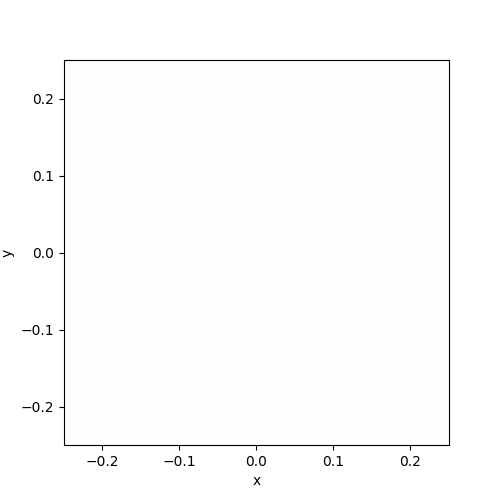

In [41]:
# EXPORT ANIMATION - create a separate figure and produce a FuncAnimation you can save or embed.
# Run this after recompute_cache() so _cache['field_coeffs'] and _cache['omega'] exist.

import matplotlib.animation as animation
from IPython.display import HTML

if _cache.get('field_coeffs') is None:
    raise RuntimeError("Please run recompute_cache() first so field_coeffs and omega are prepared.")

# Create a fresh figure for rendering the movie (keeps interactive figure intact)
fig_save, ax_save = plt.subplots(figsize=(5,5))
im_save = ax_save.imshow(np.zeros_like(X), extent=[-L,L,-L,L], origin='lower', cmap='seismic')
ax_save.set_xlabel('x')
ax_save.set_ylabel('y')

vlim = _cache.get('vlim', 1.0)
im_save.set_clim(-vlim, vlim)

def _frame_for_save(frame):
    # This uses the same fast eval function (evaluate_field) that the interactive demo uses.
    t = frame / float(fps)
    field = evaluate_field(_cache['field_coeffs'], _cache['omega'], t)
    im_save.set_data(field)
    return (im_save,)

ani = animation.FuncAnimation(fig_save, _frame_for_save,
                              frames=nframes, interval=int(1000.0/fps), blit=True)

# Option A: embed the animation as JS/HTML in the notebook (good for sharing)
#js_html = ani.to_jshtml()
#display(HTML(js_html))

# Option B: save to MP4 file (requires ffmpeg available)
# Uncomment to save to disk:
# ani.save('wavefield_animation.mp4', fps=fps, dpi=150, extra_args=['-vcodec', 'libx264'])
# print("Saved wavefield_animation.mp4")

In [ ]:
# Option A: embed the animation as JS/HTML in the notebook (good for sharing)
#js_html = ani.to_jshtml()
#display(HTML(js_html))

# Option B: save to MP4 file (requires ffmpeg available)
# Uncomment to save to disk:
ani.save('wavefield_animation.mp4', fps=fps, dpi=150, extra_args=['-vcodec', 'libx264'])
print("Saved wavefield_animation.mp4")